# Delhivery Logistics — Feature Engineering Case Study

**Business Case Study | Data Cleaning, Feature Engineering, Aggregation & Hypothesis Testing**

## 1. Problem Statement

Delhivery's raw data pipeline logs **multiple scan-level rows per package delivery** (similar to connecting-flight legs). Before any forecasting model can be built, this data needs to be **cleaned, merged, and engineered into trip-level features**. This notebook:

1. Cleans and explores the raw scan-level data.
2. **Merges rows** — first into route **segments** (source→destination legs), then into full **trips** — using appropriate aggregations (sum, first, last).
3. **Engineers features** from timestamps and location names (city, state, month/day/year).
4. Compares **actual vs. OSRM-estimated** time/distance fields via visual & statistical analysis.
5. Detects and treats **outliers**, encodes categoricals, and **scales** numeric features.
6. Surfaces **business insights** (top states, busiest corridors) and recommendations.


In [1]:
from IPython.display import display, HTML
display(HTML("<style>pre { white-space: pre-wrap !important; }</style>"))

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
np.random.seed(42)

df = pd.read_csv("delhivery_data.csv")
print(df.head())


       data          trip_creation_time  \
0  training  2018-09-20 02:35:36.476840   
1  training  2018-09-20 02:35:36.476840   
2  training  2018-09-20 02:35:36.476840   
3  training  2018-09-20 02:35:36.476840   
4  training  2018-09-20 02:35:36.476840   

                                 route_schedule_uuid route_type  \
0  thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...    Carting   
1  thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...    Carting   
2  thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...    Carting   
3  thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...    Carting   
4  thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...    Carting   

                 trip_uuid source_center                 source_name  \
0  trip-153741093647649320  IND388121AAA  Anand_VUNagar_DC (Gujarat)   
1  trip-153741093647649320  IND388121AAA  Anand_VUNagar_DC (Gujarat)   
2  trip-153741093647649320  IND388121AAA  Anand_VUNagar_DC (Gujarat)   
3  trip-153741093647649320  IND388121AAA  Anand_VU

## 2. Basic Data Checks

In [2]:
print("Shape of dataset:", df.shape)
print()
df.info()


Shape of dataset: (144867, 24)

<class 'pandas.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  str    
 1   trip_creation_time              144867 non-null  str    
 2   route_schedule_uuid             144867 non-null  str    
 3   route_type                      144867 non-null  str    
 4   trip_uuid                       144867 non-null  str    
 5   source_center                   144867 non-null  str    
 6   source_name                     144574 non-null  str    
 7   destination_center              144867 non-null  str    
 8   destination_name                144606 non-null  str    
 9   od_start_time                   144867 non-null  str    
 10  od_end_time                     144867 non-null  str    
 11  start_scan_to_end_scan          144867 non-null  float64


In [3]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print("Duplicate rows:", df.duplicated().sum())


Missing values per column:
source_name         293
destination_name    261
dtype: int64

Duplicate rows: 0


In [4]:
print("Unique trip_uuid:", df['trip_uuid'].nunique())
print("Unique route_schedule_uuid:", df['route_schedule_uuid'].nunique())
print("Unique source_center:", df['source_center'].nunique())
print("Unique destination_center:", df['destination_center'].nunique())
print()
print(df['data'].value_counts())
print(df['route_type'].value_counts())


Unique trip_uuid: 14817
Unique route_schedule_uuid: 1504
Unique source_center: 1508
Unique destination_center: 1481

data
training    104858
test         40009
Name: count, dtype: int64
route_type
FTL        99660
Carting    45207
Name: count, dtype: int64


**Observations**
- The raw file has **144,867 scan-level rows**, but only **14,817 unique trips** (`trip_uuid`) — confirming each trip is split across many rows, exactly like connecting-flight legs.
- Missing values exist only in **`source_name` (293)** and **`destination_name` (261)** — a small fraction (~0.4%) of rows. Since these text fields are essential for our City/State feature extraction and cannot be reliably imputed (no other column encodes the same city/state info in text form), we **drop these rows**.
- No duplicate rows.
- **FTL (Full Truck Load)** and **Carting** are the two `route_type` values, with FTL used in more raw scan rows — we'll see below whether this holds at the trip level too.
- The `data` column marks rows as `training` vs `test` splits (from Delhivery's own model prep); we keep this as an informational column but treat the whole file together for this EDA/feature-engineering task.

In [5]:
# Convert datetime columns (mixed formats: some rows have microseconds, some don't)
for c in ["trip_creation_time", "od_start_time", "od_end_time", "cutoff_timestamp"]:
    df[c] = pd.to_datetime(df[c], format="mixed")

# Drop rows with missing source/destination names (can't be reliably imputed for text fields)
before = len(df)
df = df.dropna(subset=["source_name", "destination_name"]).reset_index(drop=True)
print(f"Rows before: {before}, after dropping missing name rows: {len(df)}")


Rows before: 144867, after dropping missing name rows: 144316


In [6]:
print("Statistical summary (numeric columns):")
print(df.describe().T)


Statistical summary (numeric columns):
                                   count                        mean  \
trip_creation_time                144316  2018-09-22 13:05:09.454117   
od_start_time                     144316  2018-09-22 17:32:42.435769   
od_end_time                       144316  2018-09-23 09:36:54.057171   
start_scan_to_end_scan          144316.0                  963.697698   
cutoff_factor                   144316.0                  233.561345   
cutoff_timestamp                  144316  2018-09-23 02:03:47.744481   
actual_distance_to_destination  144316.0                  234.708498   
actual_time                     144316.0                  417.996237   
osrm_time                       144316.0                  214.437055   
osrm_distance                   144316.0                  285.549785   
factor                          144316.0                    2.120178   
segment_actual_time             144316.0                   36.175379   
segment_osrm_time        

**Observations**
- `actual_distance_to_destination`, `actual_time`, `osrm_time`, `osrm_distance` are all **cumulative** fields (per the column profiling) and show large ranges with **mean > median**, i.e., **right-skewed**, consistent with a few very long-haul trips alongside many short local ones.
- `segment_actual_time`, `segment_osrm_time`, `segment_osrm_distance` are the **per-scan-row (segment)** versions of the same metrics — much smaller in scale since they represent a sub-leg, not the whole cumulative trip.
- `is_cutoff` is a boolean flag; `cutoff_factor` and `factor`/`segment_factor` are ratios described as "unknown fields" in the data dictionary — we keep them for completeness but won't build core features on undocumented fields.

## 3. Merging Rows — Step 1: Segment-Level Aggregation

Each raw row is a **scan event** for one source→destination leg (segment) of a trip. Multiple scan rows can share the same segment (same `trip_uuid` + `source_center` + `destination_center`) because Delhivery logs a scan every time a "cutoff" check happens along that leg. We first collapse these into **one row per segment**.

**Approach:**
1. Create a `segment_key` = `trip_uuid` + `source_center` + `destination_center`.
2. The `segment_actual_time`, `segment_osrm_time`, `segment_osrm_distance` columns are **incremental per scan**, so we `cumsum()` them within each `segment_key` to get running totals, then keep the **last** (i.e., final/total) value per segment as `..._sum`.
3. For fields that are already **cumulative for the whole trip up to that point** (`actual_time`, `osrm_time`, `osrm_distance`, `actual_distance_to_destination`, `start_scan_to_end_scan`), we take the **last** value per segment (the latest/most complete scan).
4. For identifying/categorical fields (`source_center`, `source_name`, `trip_creation_time`, `route_type`, etc.) we take **first**; for the fields that describe the segment's end (`destination_center`, `destination_name`, `od_end_time`) we take **last**.

In [7]:
df["segment_key"] = df["trip_uuid"] + "_" + df["source_center"] + "_" + df["destination_center"]

for c in ["segment_actual_time", "segment_osrm_time", "segment_osrm_distance"]:
    df[c + "_sum"] = df.groupby("segment_key")[c].cumsum()

print(f"Raw rows: {len(df)}, unique segment_key values: {df['segment_key'].nunique()}")


Raw rows: 144316, unique segment_key values: 26222


In [8]:
create_segment_dict = {
    "source_center": "first", "source_name": "first",
    "destination_center": "last", "destination_name": "last",
    "od_start_time": "first", "od_end_time": "last",
    "start_scan_to_end_scan": "last",
    "actual_distance_to_destination": "last",
    "actual_time": "last", "osrm_time": "last", "osrm_distance": "last",
    "segment_actual_time_sum": "last", "segment_osrm_time_sum": "last", "segment_osrm_distance_sum": "last",
    "trip_creation_time": "first", "route_type": "first", "trip_uuid": "first",
}

segment = df.groupby("segment_key", as_index=False).agg(create_segment_dict)
segment = segment.sort_values(["segment_key", "od_end_time"]).reset_index(drop=True)

print("Segment-level shape:", segment.shape)
print(segment.head())


Segment-level shape: (26222, 18)
                                         segment_key source_center  \
0  trip-153671041653548748_IND209304AAA_IND000000ACB  IND209304AAA   
1  trip-153671041653548748_IND462022AAA_IND209304AAA  IND462022AAA   
2  trip-153671042288605164_IND561203AAB_IND562101AAA  IND561203AAB   
3  trip-153671042288605164_IND572101AAA_IND561203AAB  IND572101AAA   
4  trip-153671043369099517_IND000000ACB_IND160002AAC  IND000000ACB   

                          source_name destination_center  \
0  Kanpur_Central_H_6 (Uttar Pradesh)       IND000000ACB   
1  Bhopal_Trnsport_H (Madhya Pradesh)       IND209304AAA   
2   Doddablpur_ChikaDPP_D (Karnataka)       IND562101AAA   
3       Tumkur_Veersagr_I (Karnataka)       IND561203AAB   
4       Gurgaon_Bilaspur_HB (Haryana)       IND160002AAC   

                     destination_name              od_start_time  \
0       Gurgaon_Bilaspur_HB (Haryana) 2018-09-12 16:39:46.858469   
1  Kanpur_Central_H_6 (Uttar Pradesh) 2018-09-12 

## 4. Merging Rows — Step 2: Trip-Level Aggregation

Now we collapse **segments belonging to the same trip** (`trip_uuid`) into one row per trip. Since each segment's `actual_time`/`osrm_time`/`osrm_distance`/`start_scan_to_end_scan` is the **total for that leg**, summing them across all legs of a trip gives the trip's overall total — this is the natural aggregation for "connecting-flight"-style data.

In [9]:
create_trip_dict = {
    "source_center": "first", "source_name": "first",
    "destination_center": "last", "destination_name": "last",
    "od_start_time": "first", "od_end_time": "last",
    "start_scan_to_end_scan": "sum",
    "actual_distance_to_destination": "sum",
    "actual_time": "sum", "osrm_time": "sum", "osrm_distance": "sum",
    "segment_actual_time_sum": "sum", "segment_osrm_time_sum": "sum", "segment_osrm_distance_sum": "sum",
    "trip_creation_time": "first", "route_type": "first",
}

trip = segment.groupby("trip_uuid", as_index=False).agg(create_trip_dict)
print("Trip-level shape:", trip.shape)
print(trip.head())


Trip-level shape: (14787, 17)
                 trip_uuid source_center                         source_name  \
0  trip-153671041653548748  IND209304AAA  Kanpur_Central_H_6 (Uttar Pradesh)   
1  trip-153671042288605164  IND561203AAB   Doddablpur_ChikaDPP_D (Karnataka)   
2  trip-153671043369099517  IND000000ACB       Gurgaon_Bilaspur_HB (Haryana)   
3  trip-153671046011330457  IND400072AAB            Mumbai Hub (Maharashtra)   
4  trip-153671052974046625  IND583101AAA              Bellary_Dc (Karnataka)   

  destination_center                    destination_name  \
0       IND209304AAA  Kanpur_Central_H_6 (Uttar Pradesh)   
1       IND561203AAB   Doddablpur_ChikaDPP_D (Karnataka)   
2       IND000000ACB       Gurgaon_Bilaspur_HB (Haryana)   
3       IND401104AAA      Mumbai_MiraRd_IP (Maharashtra)   
4       IND583119AAA       Sandur_WrdN1DPP_D (Karnataka)   

               od_start_time                od_end_time  \
0 2018-09-12 16:39:46.858469 2018-09-12 16:39:46.858469   
1 2018-09-

**Result:** We've gone from **144,316 scan rows -> 26,222 segments -> 14,787 trips**. Every subsequent analysis in this notebook (EDA, hypothesis testing, outliers, encoding, scaling) works on this clean, one-row-per-trip `trip` DataFrame.

## 5. Feature Engineering

### 5.1 Trip duration feature: `od_time_diff_hour`

In [10]:
trip["od_time_diff_hour"] = (trip["od_end_time"] - trip["od_start_time"]).dt.total_seconds() / 3600
trip = trip.drop(columns=["od_start_time", "od_end_time"])
print(trip[["trip_uuid", "od_time_diff_hour"]].describe())


       od_time_diff_hour
count       14787.000000
mean            6.162093
std             9.604992
min           -28.174441
25%             1.585154
50%             3.266970
75%             6.711362
max           131.642533


### 5.2 Source & Destination — City / State extraction

Both `source_name` and `destination_name` follow the pattern **`City_place_code (State)`** (e.g., `"Khambhat_MotvdDPP_D (Gujarat)"`). We split out the **City** (text before the first underscore) and the **State** (text inside the parentheses).

In [11]:
trip["source_city"] = trip["source_name"].str.split("_").str[0]
trip["source_state"] = trip["source_name"].str.extract(r"\(([^)]+)\)")
trip["destination_city"] = trip["destination_name"].str.split("_").str[0]
trip["destination_state"] = trip["destination_name"].str.extract(r"\(([^)]+)\)")

print(trip[["source_name","source_city","source_state","destination_name","destination_city","destination_state"]].head())


                          source_name               source_city  \
0  Kanpur_Central_H_6 (Uttar Pradesh)                    Kanpur   
1   Doddablpur_ChikaDPP_D (Karnataka)                Doddablpur   
2       Gurgaon_Bilaspur_HB (Haryana)                   Gurgaon   
3            Mumbai Hub (Maharashtra)  Mumbai Hub (Maharashtra)   
4              Bellary_Dc (Karnataka)                   Bellary   

    source_state                    destination_name destination_city  \
0  Uttar Pradesh  Kanpur_Central_H_6 (Uttar Pradesh)           Kanpur   
1      Karnataka   Doddablpur_ChikaDPP_D (Karnataka)       Doddablpur   
2        Haryana       Gurgaon_Bilaspur_HB (Haryana)          Gurgaon   
3    Maharashtra      Mumbai_MiraRd_IP (Maharashtra)           Mumbai   
4      Karnataka       Sandur_WrdN1DPP_D (Karnataka)           Sandur   

  destination_state  
0     Uttar Pradesh  
1         Karnataka  
2           Haryana  
3       Maharashtra  
4         Karnataka  


### 5.3 Trip creation time — Month / Day / Year / Hour

In [12]:
trip["trip_creation_year"] = trip["trip_creation_time"].dt.year
trip["trip_creation_month"] = trip["trip_creation_time"].dt.month
trip["trip_creation_day"] = trip["trip_creation_time"].dt.day
trip["trip_creation_hour"] = trip["trip_creation_time"].dt.hour
trip["trip_creation_dayofweek"] = trip["trip_creation_time"].dt.day_name()

print(trip[["trip_creation_time","trip_creation_year","trip_creation_month","trip_creation_day","trip_creation_hour","trip_creation_dayofweek"]].head())


          trip_creation_time  trip_creation_year  trip_creation_month  \
0 2018-09-12 00:00:16.535741                2018                    9   
1 2018-09-12 00:00:22.886430                2018                    9   
2 2018-09-12 00:00:33.691250                2018                    9   
3 2018-09-12 00:01:00.113710                2018                    9   
4 2018-09-12 00:02:09.740725                2018                    9   

   trip_creation_day  trip_creation_hour trip_creation_dayofweek  
0                 12                   0               Wednesday  
1                 12                   0               Wednesday  
2                 12                   0               Wednesday  
3                 12                   0               Wednesday  
4                 12                   0               Wednesday  


### 5.4 Corridor feature (for business insights later)

In [13]:
trip["corridor"] = trip["source_city"] + " -> " + trip["destination_city"]
print(trip["corridor"].nunique(), "unique corridors")


1752 unique corridors


**Observations**
- `trip_creation_year` shows the data spans a short window (all of it in **2018, from mid-September to early October**), so `year` won't be a useful predictor on its own for this dataset, but `month`, `day`, `hour`, and `day of week` will show meaningful intra-period patterns (explored in Section 6).
- We now have clean **City** and **State** features for both source and destination, letting us answer "where do most orders come from" and "what's the busiest corridor" later in the business insights section.

## 6. Exploratory Data Analysis (Trip-Level)

### 6.1 Continuous variables — distributions

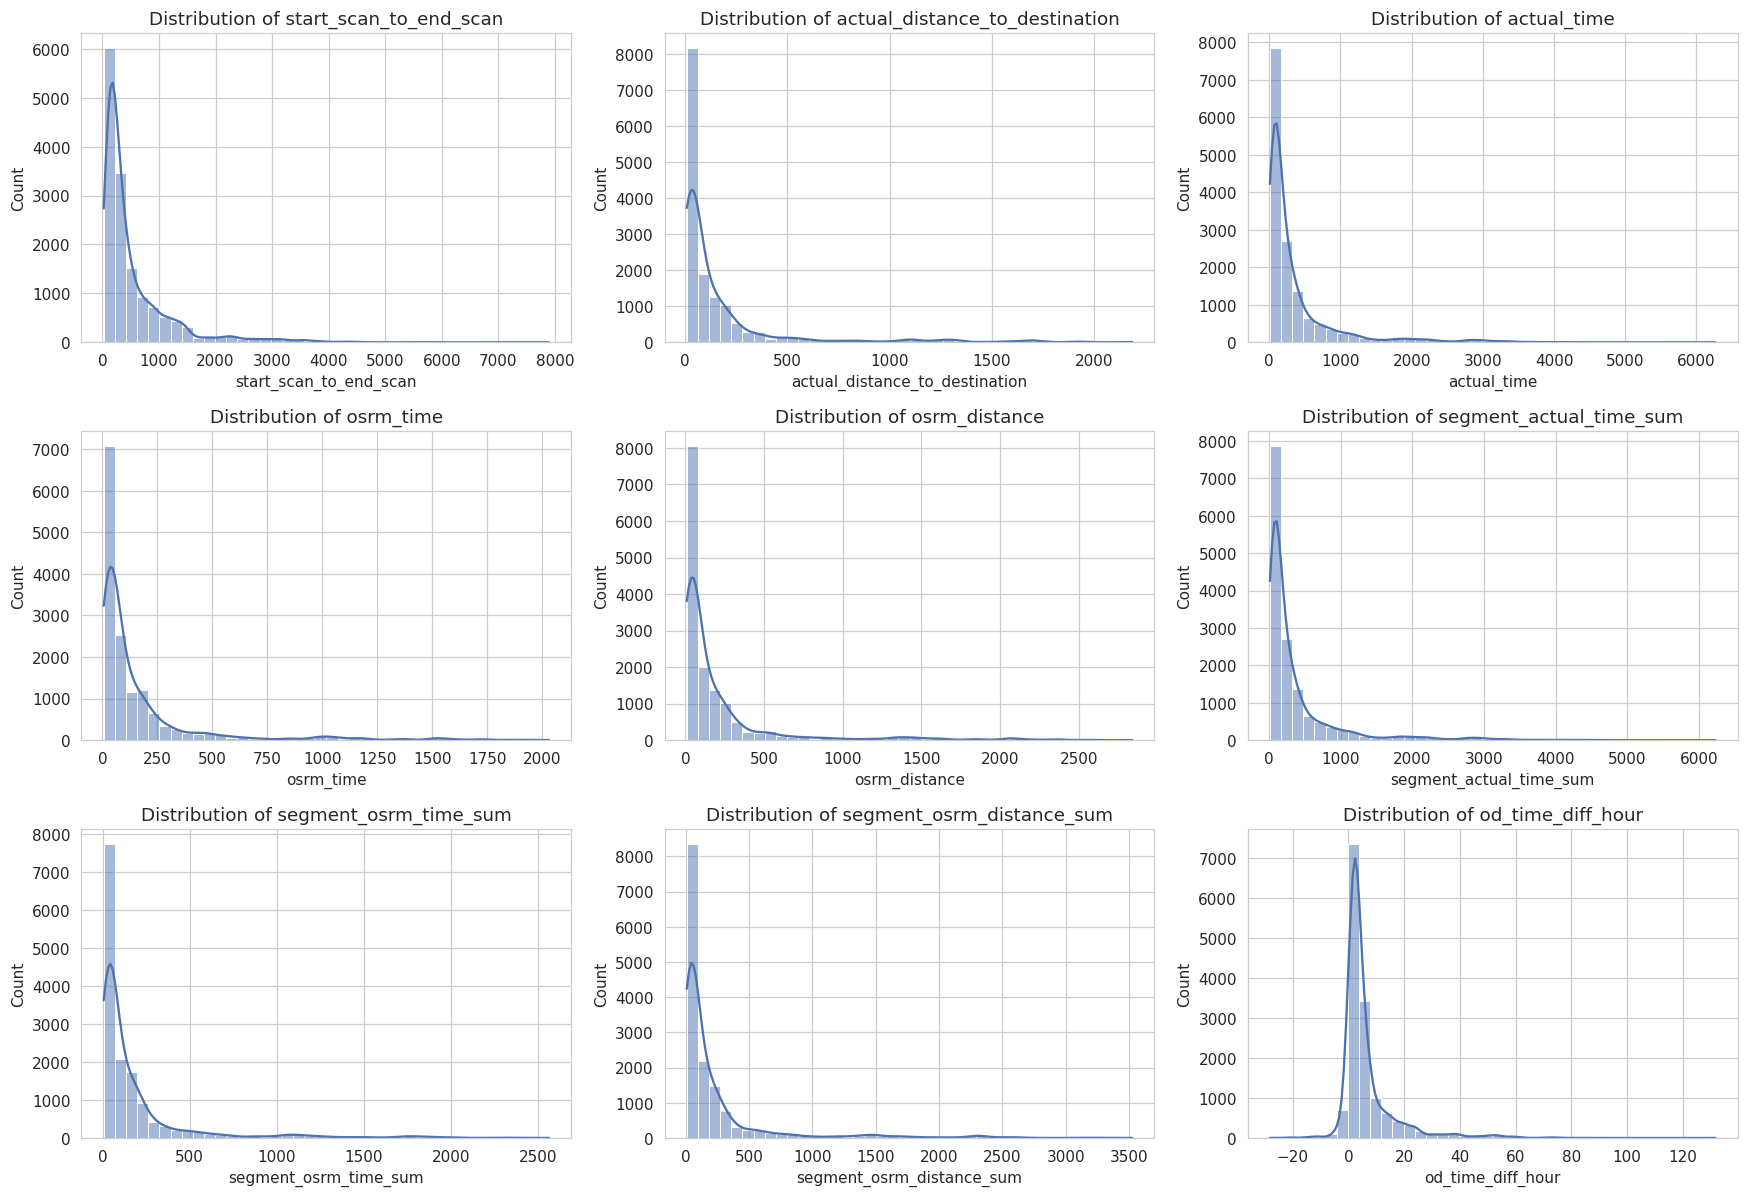

In [14]:
num_cols = ["start_scan_to_end_scan", "actual_distance_to_destination", "actual_time",
            "osrm_time", "osrm_distance", "segment_actual_time_sum",
            "segment_osrm_time_sum", "segment_osrm_distance_sum", "od_time_diff_hour"]

fig, axes = plt.subplots(3, 3, figsize=(16, 11))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(trip[col], kde=True, ax=ax, bins=40, color="#4C72B0")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()


### 6.2 Categorical variables — count plots

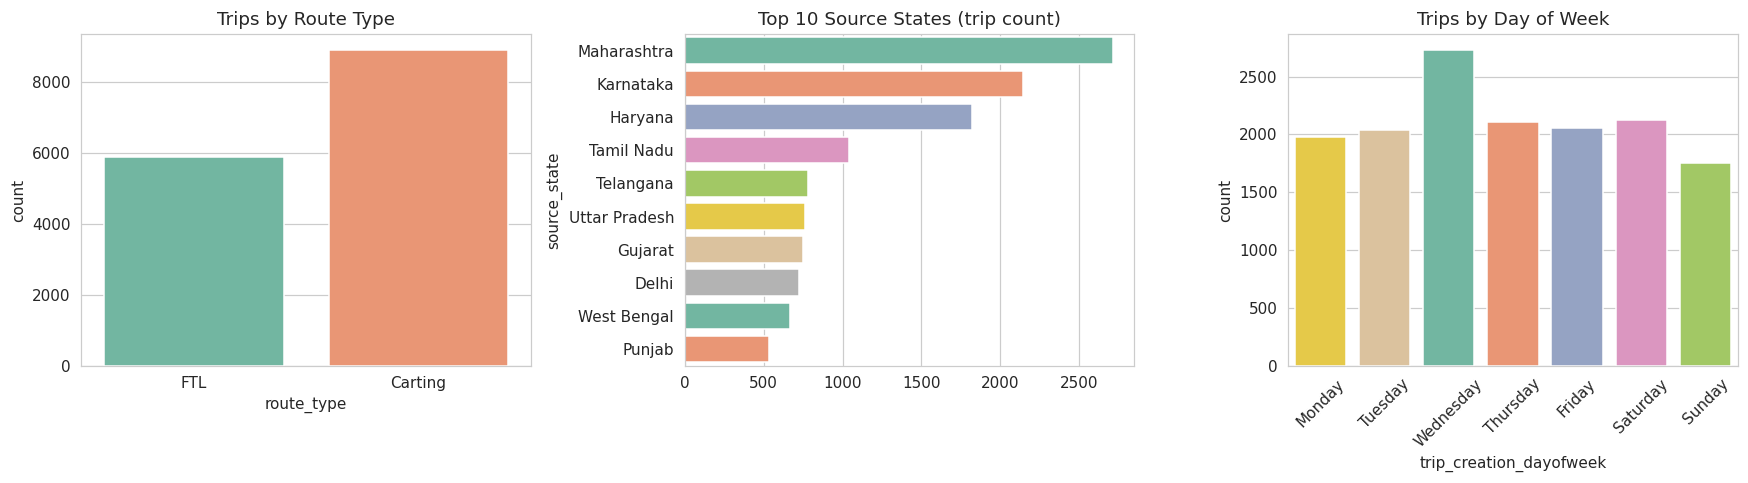

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.countplot(x="route_type", data=trip, ax=axes[0], hue="route_type", palette="Set2", legend=False)
axes[0].set_title("Trips by Route Type")
top_states = trip["source_state"].value_counts().head(10)
sns.barplot(x=top_states.values, y=top_states.index, ax=axes[1], hue=top_states.index, palette="Set2", legend=False)
axes[1].set_title("Top 10 Source States (trip count)")
sns.countplot(x="trip_creation_dayofweek", data=trip, ax=axes[2],
              order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"],
              hue="trip_creation_dayofweek", palette="Set2", legend=False)
axes[2].set_title("Trips by Day of Week")
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


**Observations**
- All the time/distance fields (`actual_time`, `osrm_time`, `osrm_distance`, `start_scan_to_end_scan`, the `segment_..._sum` fields, `od_time_diff_hour`) are **heavily right-skewed** — most trips are short/local, with a long tail of long-haul trips.
- **Carting trips outnumber FTL trips** at the trip level (unlike the raw scan-row counts, where FTL rows dominated — this flips because FTL trips tend to have fewer, longer segments while Carting trips are split into many more scan rows per trip).
- **Maharashtra, Karnataka, and Haryana are the top source states**, reflecting Delhivery's densest operating hubs (Mumbai, Bengaluru, Gurgaon-Delhi NCR).
- Trip creation is fairly evenly spread across days of the week, with only mild dips/peaks — no extreme weekday/weekend effect visible at a glance.

### 6.3 Bivariate — Route Type vs Time/Distance

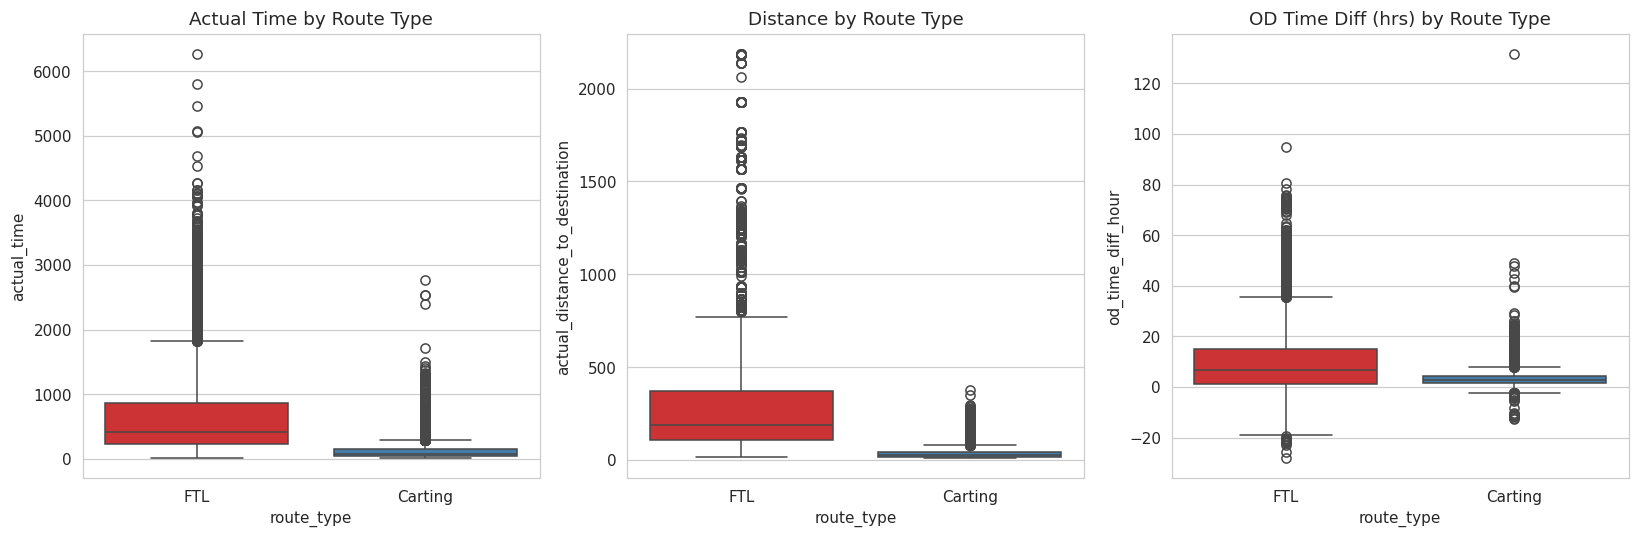

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(x="route_type", y="actual_time", data=trip, ax=axes[0], hue="route_type", palette="Set1", legend=False)
axes[0].set_title("Actual Time by Route Type")
sns.boxplot(x="route_type", y="actual_distance_to_destination", data=trip, ax=axes[1], hue="route_type", palette="Set1", legend=False)
axes[1].set_title("Distance by Route Type")
sns.boxplot(x="route_type", y="od_time_diff_hour", data=trip, ax=axes[2], hue="route_type", palette="Set1", legend=False)
axes[2].set_title("OD Time Diff (hrs) by Route Type")
plt.tight_layout()
plt.show()


**Observations**
- **FTL trips tend to cover longer distances and take more actual time** than Carting trips — consistent with FTL being used for direct, longer-haul shipments, while Carting handles shorter, local, multi-stop legs.
- Both route types show **wide spread and many high-end outliers** in time/distance — long-haul trips exist in both categories, but are more common/extreme for FTL.

## 7. Correlation Analysis

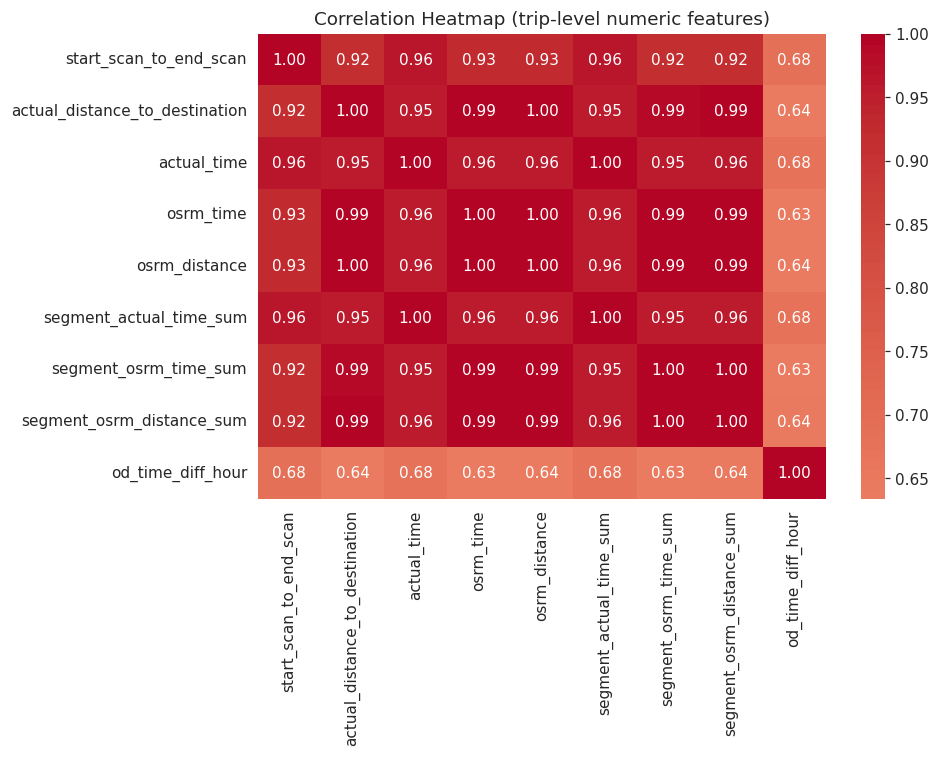

In [17]:
plt.figure(figsize=(9,7))
sns.heatmap(trip[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (trip-level numeric features)")
plt.tight_layout()
plt.show()


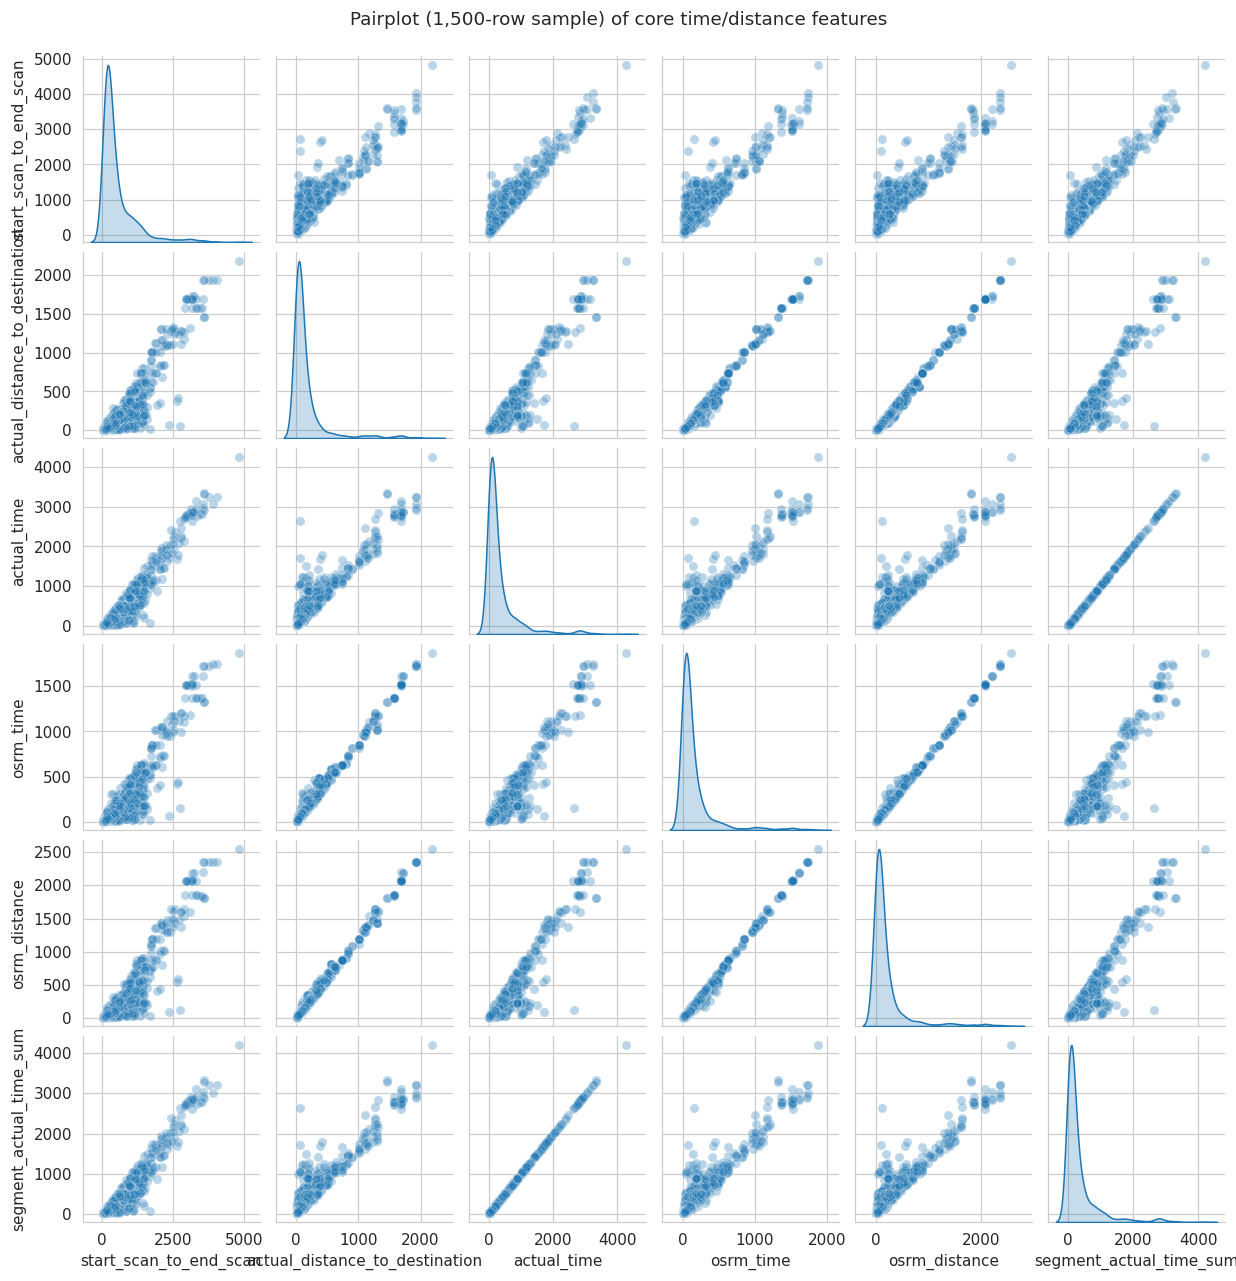

In [18]:
sample_trip = trip.sample(1500, random_state=1)
sns.pairplot(sample_trip[num_cols[:6]], diag_kind="kde", height=1.9, plot_kws={"alpha":0.3})
plt.suptitle("Pairplot (1,500-row sample) of core time/distance features", y=1.02)
plt.show()


**Observations**
- **`actual_time`, `osrm_time`, `osrm_distance`, `actual_distance_to_destination`, `start_scan_to_end_scan`, and the `segment_..._sum` fields are all very highly correlated with each other (mostly 0.9+)** — they're all, fundamentally, different measurements of "how big/long was this trip." This is expected and means many of these features carry **redundant/overlapping information**.
- `od_time_diff_hour` correlates moderately (~0.6-0.7) with the other time/distance fields — related, but clearly capturing something slightly different (the wall-clock gap between trip start and end, vs. cumulative scan-based time).
- **Practical implication for modeling:** if Delhivery's data science team builds a forecasting model on this data, they should **drop or combine highly-correlated features** (e.g., keep `osrm_distance` and `actual_time`, drop the near-duplicate segment-sum columns) to avoid multicollinearity.

## 8. Comparing Actual vs. OSRM-Estimated Time & Distance

Delhivery's raw data captures both **real-world (actual/scan-based)** metrics and **OSRM (map-routing engine) estimates**. We compare these pairs using paired t-tests (since each pair of measurements describes the *same* trip) plus visual analysis, at **α = 0.05**.

### 8.1 `start_scan_to_end_scan` vs `od_time_diff_hour` (×60, to compare in minutes)

**H0:** No difference between the scan-based delivery duration and the wall-clock OD start/end duration.
**H1:** There is a significant difference between the two.

In [19]:
a = trip["start_scan_to_end_scan"]
b = trip["od_time_diff_hour"] * 60

print(f"start_scan_to_end_scan: mean={a.mean():.1f} min, median={a.median():.1f} min")
print(f"od_time_diff_hour*60:   mean={b.mean():.1f} min, median={b.median():.1f} min")

t_stat, p_value = stats.ttest_rel(a, b)
print(f"\nPaired t-test: t={t_stat:.3f}, p-value={p_value:.3e}")
alpha = 0.05
print("REJECT H0" if p_value <= alpha else "FAIL TO REJECT H0", f"(alpha={alpha})")


start_scan_to_end_scan: mean=529.4 min, median=279.0 min
od_time_diff_hour*60:   mean=369.7 min, median=196.0 min

Paired t-test: t=39.052, p-value=0.000e+00
REJECT H0 (alpha=0.05)


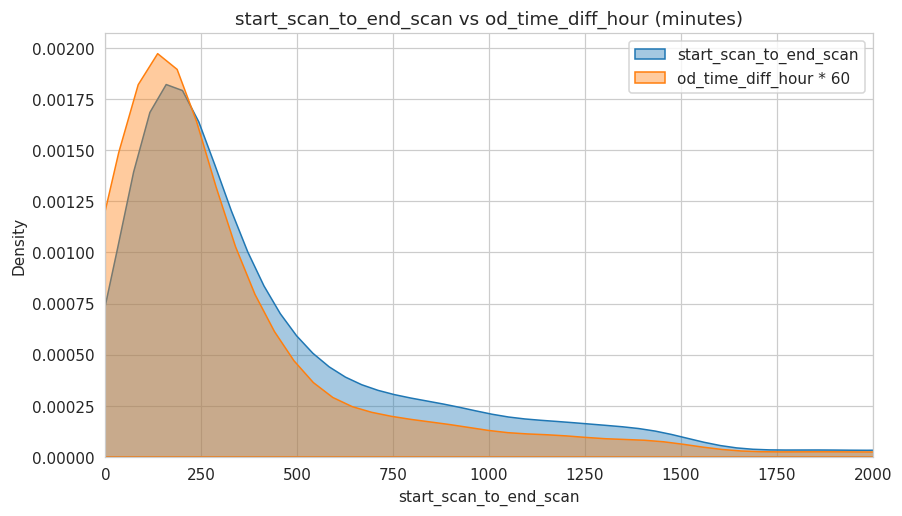

In [20]:
plt.figure(figsize=(9,5))
sns.kdeplot(a, label="start_scan_to_end_scan", fill=True, alpha=0.4)
sns.kdeplot(b, label="od_time_diff_hour * 60", fill=True, alpha=0.4)
plt.xlim(0, 2000)
plt.title("start_scan_to_end_scan vs od_time_diff_hour (minutes)")
plt.legend()
plt.show()


**Conclusion:** p-value « 0.05 -> **reject H0**. The scan-based duration (`start_scan_to_end_scan`, mean ≈529 min) is on average **~160 minutes longer** than the wall-clock OD duration (`od_time_diff_hour*60`, mean ≈370 min). **Inference:** the `od_start_time`/`od_end_time` timestamps likely capture only the *active movement* window, while `start_scan_to_end_scan` also includes **waiting/handling time at hubs** (sorting, loading, cutoff waits) — a real operational gap worth investigating for efficiency gains.

### 8.2 `actual_time` (aggregated) vs `osrm_time` (aggregated)

**H0:** No difference between actual delivery time and OSRM's estimated time.
**H1:** There is a significant difference.

In [21]:
print(f"actual_time: mean={trip['actual_time'].mean():.1f} min, median={trip['actual_time'].median():.1f} min")
print(f"osrm_time:   mean={trip['osrm_time'].mean():.1f} min, median={trip['osrm_time'].median():.1f} min")

t_stat, p_value = stats.ttest_rel(trip["actual_time"], trip["osrm_time"])
print(f"\nPaired t-test: t={t_stat:.3f}, p-value={p_value:.3e}")
print("REJECT H0" if p_value <= alpha else "FAIL TO REJECT H0", f"(alpha={alpha})")


actual_time: mean=356.3 min, median=148.0 min
osrm_time:   mean=161.0 min, median=60.0 min

Paired t-test: t=76.377, p-value=0.000e+00
REJECT H0 (alpha=0.05)


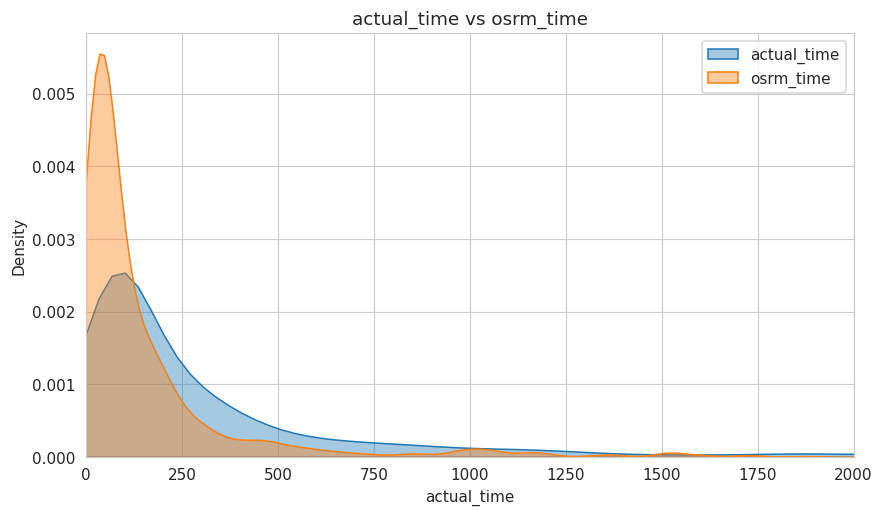

In [22]:
plt.figure(figsize=(9,5))
sns.kdeplot(trip["actual_time"], label="actual_time", fill=True, alpha=0.4)
sns.kdeplot(trip["osrm_time"], label="osrm_time", fill=True, alpha=0.4)
plt.xlim(0, 2000)
plt.title("actual_time vs osrm_time")
plt.legend()
plt.show()


**Conclusion:** p-value « 0.05 -> **reject H0**. Real deliveries take, on average, **actual_time ≈356 min vs osrm_time ≈161 min** — actual delivery time is more than **2x** the OSRM (pure-routing) estimate. **Inference:** OSRM only models road-network travel time and ignores loading/unloading, hub sorting, traffic beyond its model, and waiting — Delhivery should **not use raw OSRM time as a customer-facing ETA**; a correction factor (or a model trained on the actual-vs-OSRM gap) is needed.

### 8.3 `actual_time` (aggregated) vs `segment_actual_time_sum` (aggregated)

**H0:** No difference between the trip-level actual time and the sum of segment-level actual times.
**H1:** There is a significant difference.

In [23]:
print(f"actual_time (trip):            mean={trip['actual_time'].mean():.1f} min")
print(f"segment_actual_time_sum (trip): mean={trip['segment_actual_time_sum'].mean():.1f} min")

t_stat, p_value = stats.ttest_rel(trip["actual_time"], trip["segment_actual_time_sum"])
print(f"\nPaired t-test: t={t_stat:.3f}, p-value={p_value:.3e}")
print("REJECT H0" if p_value <= alpha else "FAIL TO REJECT H0", f"(alpha={alpha})")


actual_time (trip):            mean=356.3 min
segment_actual_time_sum (trip): mean=353.1 min

Paired t-test: t=68.263, p-value=0.000e+00
REJECT H0 (alpha=0.05)


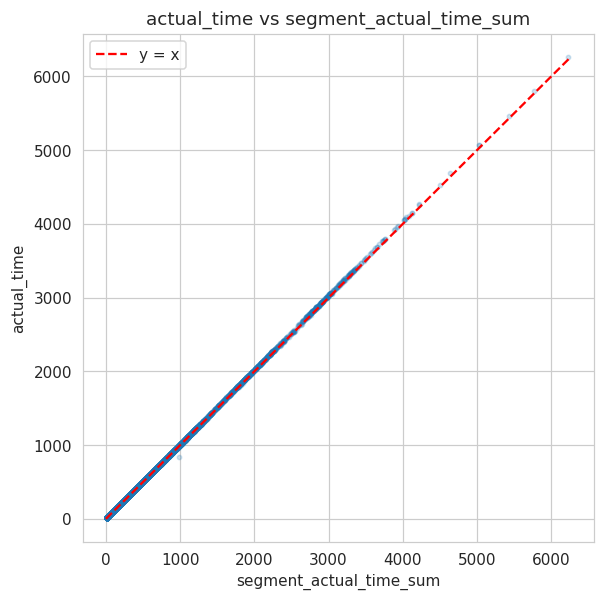

In [24]:
plt.figure(figsize=(6,6))
plt.scatter(trip["segment_actual_time_sum"], trip["actual_time"], alpha=0.2, s=8)
lims = [0, trip[["actual_time","segment_actual_time_sum"]].max().max()]
plt.plot(lims, lims, "r--", label="y = x")
plt.xlabel("segment_actual_time_sum"); plt.ylabel("actual_time")
plt.title("actual_time vs segment_actual_time_sum")
plt.legend()
plt.show()


**Conclusion:** p-value « 0.05 -> statistically, **reject H0**, but the practical gap is tiny (~356.3 vs ~353.1 minutes, a difference of only ~3 minutes, or <1%) — the scatter plot sits almost exactly on the `y=x` line. **Inference:** with over 14,000 trips, even a trivial average difference becomes "statistically significant" — this is a good example of **statistical significance not implying practical/business significance**. These two measures are, for all practical purposes, **interchangeable**, which is reassuring: it confirms our segment-to-trip aggregation logic is internally consistent.

### 8.4 `osrm_distance` (aggregated) vs `segment_osrm_distance_sum` (aggregated)

**H0:** No difference between trip-level OSRM distance and the sum of segment-level OSRM distances.
**H1:** There is a significant difference.

In [25]:
print(f"osrm_distance (trip):             mean={trip['osrm_distance'].mean():.1f} km")
print(f"segment_osrm_distance_sum (trip): mean={trip['segment_osrm_distance_sum'].mean():.1f} km")

t_stat, p_value = stats.ttest_rel(trip["osrm_distance"], trip["segment_osrm_distance_sum"])
print(f"\nPaired t-test: t={t_stat:.3f}, p-value={p_value:.3e}")
print("REJECT H0" if p_value <= alpha else "FAIL TO REJECT H0", f"(alpha={alpha})")


osrm_distance (trip):             mean=203.9 km
segment_osrm_distance_sum (trip): mean=222.7 km

Paired t-test: t=-37.241, p-value=3.046e-290
REJECT H0 (alpha=0.05)


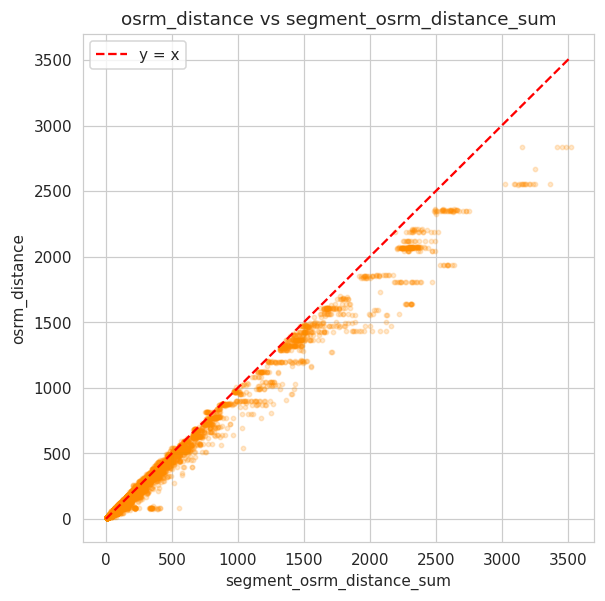

In [26]:
plt.figure(figsize=(6,6))
plt.scatter(trip["segment_osrm_distance_sum"], trip["osrm_distance"], alpha=0.2, s=8, color="darkorange")
lims = [0, trip[["osrm_distance","segment_osrm_distance_sum"]].max().max()]
plt.plot(lims, lims, "r--", label="y = x")
plt.xlabel("segment_osrm_distance_sum"); plt.ylabel("osrm_distance")
plt.title("osrm_distance vs segment_osrm_distance_sum")
plt.legend()
plt.show()


**Conclusion:** p-value « 0.05 -> **reject H0**. Here the gap is more noticeable: `segment_osrm_distance_sum` (≈223 km) runs **~19 km higher on average** than the trip-level `osrm_distance` (≈204 km). **Inference:** summing segment-level OSRM distances slightly **over-counts** versus the trip-level cumulative figure — likely because segment-level routing is recalculated independently for each leg (potentially through slightly different waypoints) rather than being a perfect breakdown of one continuous trip route. Delhivery's routing team should decide which of the two is the "source of truth" for distance-based costing (e.g., fuel, pricing).

### 8.5 `osrm_time` (aggregated) vs `segment_osrm_time_sum` (aggregated)

**H0:** No difference between trip-level OSRM time and the sum of segment-level OSRM times.
**H1:** There is a significant difference.

In [27]:
print(f"osrm_time (trip):             mean={trip['osrm_time'].mean():.1f} min")
print(f"segment_osrm_time_sum (trip): mean={trip['segment_osrm_time_sum'].mean():.1f} min")

t_stat, p_value = stats.ttest_rel(trip["osrm_time"], trip["segment_osrm_time_sum"])
print(f"\nPaired t-test: t={t_stat:.3f}, p-value={p_value:.3e}")
print("REJECT H0" if p_value <= alpha else "FAIL TO REJECT H0", f"(alpha={alpha})")


osrm_time (trip):             mean=161.0 min
segment_osrm_time_sum (trip): mean=180.5 min

Paired t-test: t=-43.203, p-value=0.000e+00
REJECT H0 (alpha=0.05)


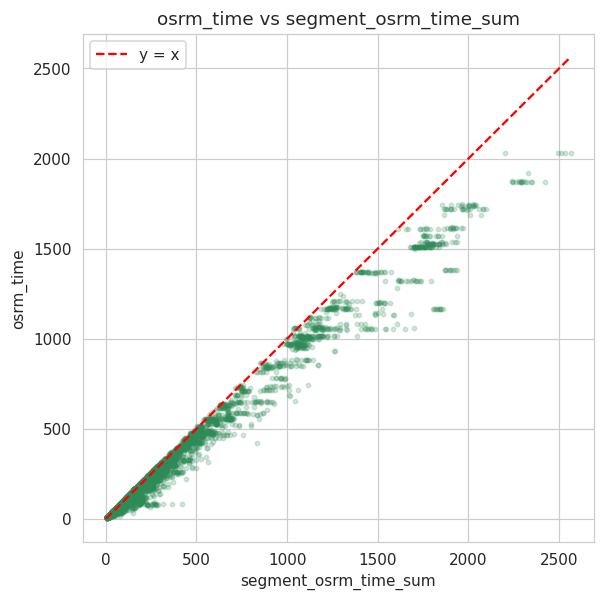

In [28]:
plt.figure(figsize=(6,6))
plt.scatter(trip["segment_osrm_time_sum"], trip["osrm_time"], alpha=0.2, s=8, color="seagreen")
lims = [0, trip[["osrm_time","segment_osrm_time_sum"]].max().max()]
plt.plot(lims, lims, "r--", label="y = x")
plt.xlabel("segment_osrm_time_sum"); plt.ylabel("osrm_time")
plt.title("osrm_time vs segment_osrm_time_sum")
plt.legend()
plt.show()


**Conclusion:** p-value « 0.05 -> **reject H0**. Similar pattern to distance: `segment_osrm_time_sum` (≈181 min) is **~20 minutes higher on average** than trip-level `osrm_time` (≈161 min) — the same segment-level over-counting effect as seen for distance in 8.4, which makes sense since OSRM time and distance are derived from the same underlying route calculation.

## 9. Outlier Detection & Treatment (IQR Method)

### 9.1 Visualizing outliers

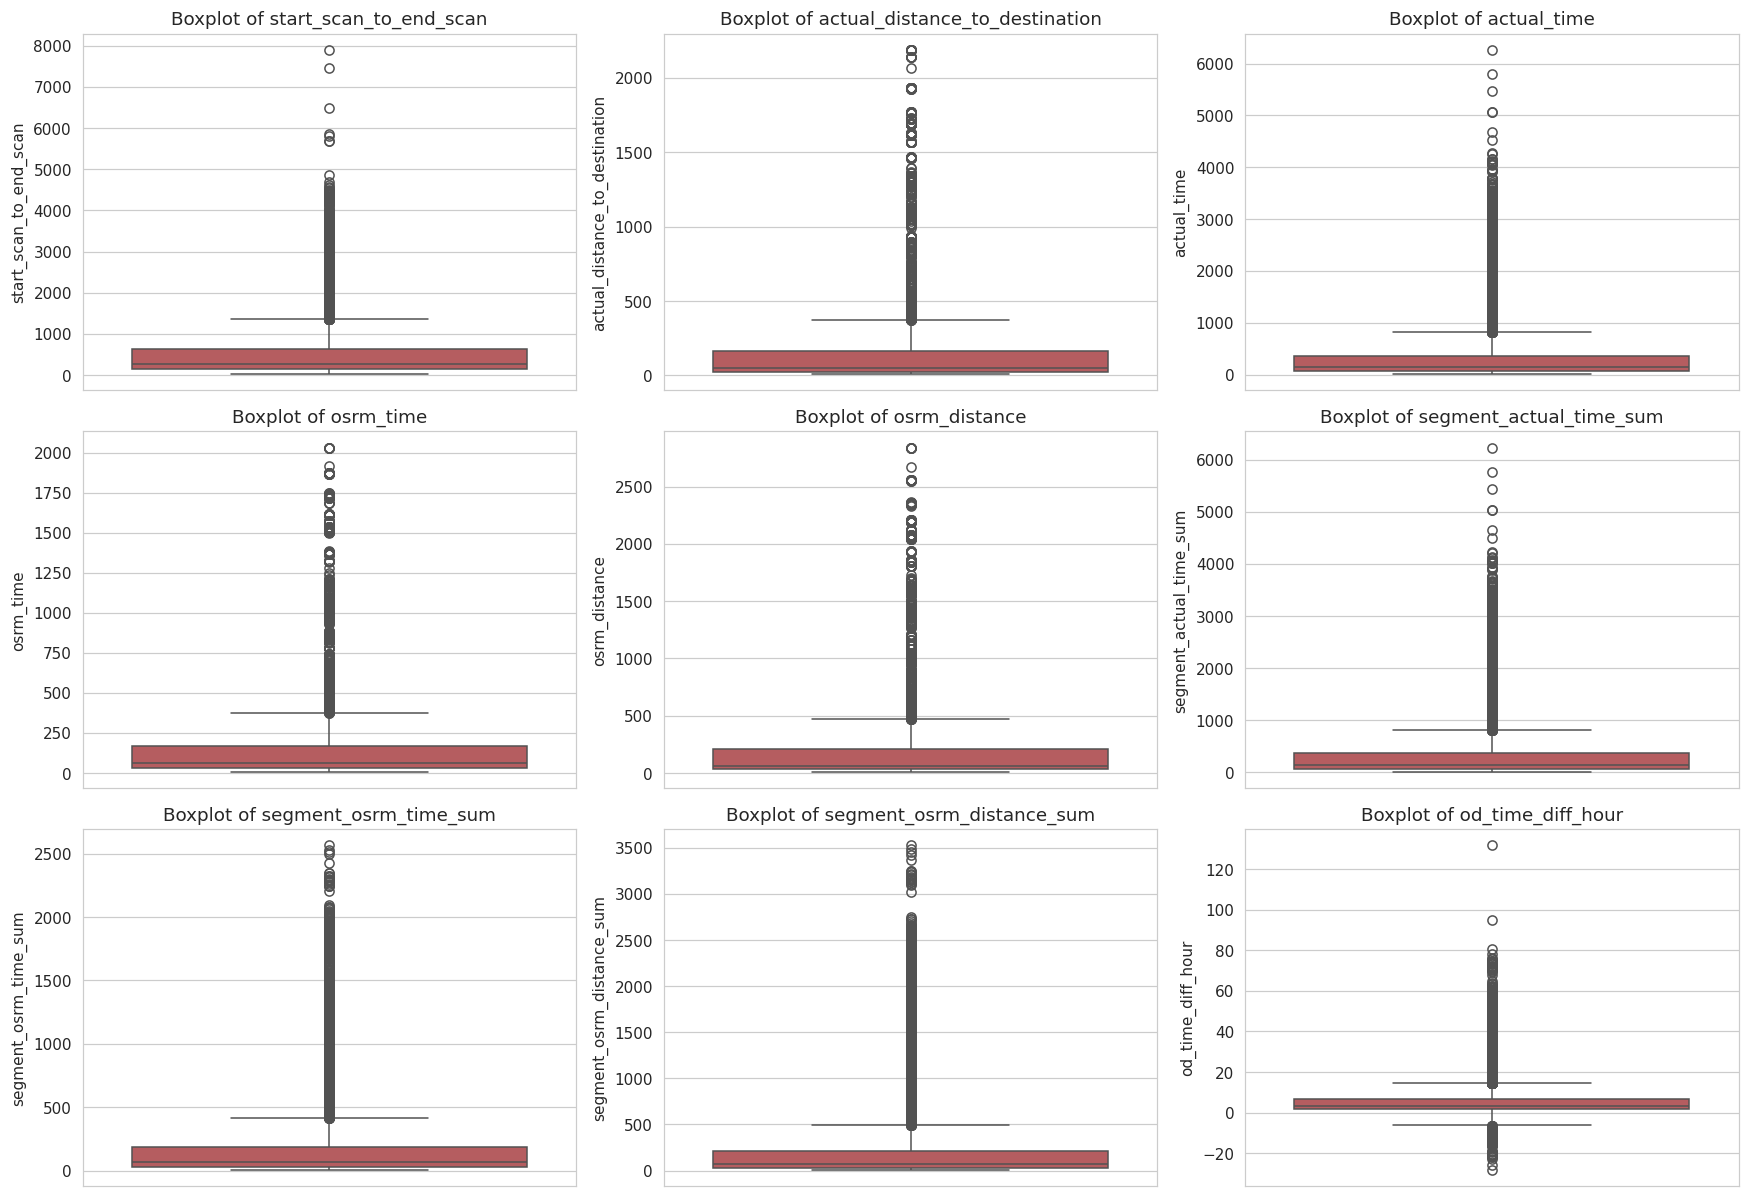

In [29]:
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=trip[col], ax=ax, color="#C44E52")
    ax.set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()


In [30]:
def outlier_bounds(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

outlier_report = []
for c in num_cols:
    lo, hi = outlier_bounds(trip[c])
    n_out = ((trip[c] < lo) | (trip[c] > hi)).sum()
    outlier_report.append([c, round(lo,1), round(hi,1), n_out, round(n_out/len(trip)*100,1)])

outlier_df = pd.DataFrame(outlier_report, columns=["Column","Lower","Upper","n_outliers","pct_outliers"])
print(outlier_df)


                           Column  Lower   Upper  n_outliers  pct_outliers
0          start_scan_to_end_scan -575.5  1356.5        1282           8.7
1  actual_distance_to_destination -188.4   374.8        1452           9.8
2                     actual_time -383.0   817.0        1646          11.1
3                       osrm_time -179.5   376.5        1506          10.2
4                   osrm_distance -233.1   470.5        1522          10.3
5         segment_actual_time_sum -381.0   811.0        1644          11.1
6           segment_osrm_time_sum -201.0   415.0        1485          10.0
7       segment_osrm_distance_sum -243.4   492.5        1550          10.5
8               od_time_diff_hour   -6.1    14.4        1778          12.0


**Observations:** As expected for logistics data, **every numeric field shows outliers on the high side (~9-12% of trips)** — these are the genuine **long-haul, cross-state trips** (large distance, large time), not data errors. Removing them entirely would throw away exactly the trips that matter most for understanding Delhivery's long-distance network performance. We therefore use the standard **IQR-capping (clipping)** approach — pulling extreme values in to the IQR boundary — rather than deleting rows, so we keep every trip but reduce the influence of extreme values on scaling/model training.

### 9.2 Treating outliers — IQR capping

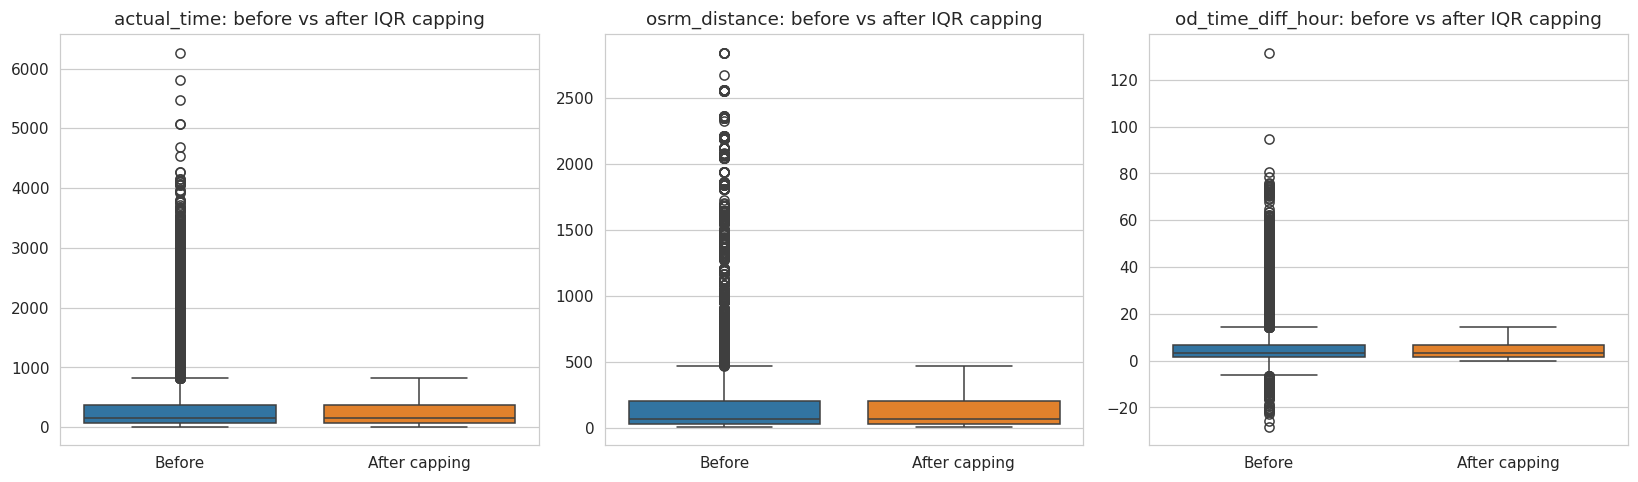

In [31]:
trip_capped = trip.copy()
for c in num_cols:
    lo, hi = outlier_bounds(trip[c])
    trip_capped[c] = trip_capped[c].clip(lower=max(lo, 0), upper=hi)

fig, axes = plt.subplots(1, 3, figsize=(15,4.5))
for ax, col in zip(axes, ["actual_time", "osrm_distance", "od_time_diff_hour"]):
    sns.boxplot(data=pd.DataFrame({"Before": trip[col], "After capping": trip_capped[col]}), ax=ax)
    ax.set_title(f"{col}: before vs after IQR capping")
plt.tight_layout()
plt.show()


**Result:** After capping, extreme long-haul trips are pulled in to the IQR boundary rather than removed — the boxplots confirm the extreme whiskers are gone while the bulk of the distribution (and every trip record) is preserved. We proceed with `trip_capped` for the encoding/scaling steps below.

## 10. Handling Categorical Variables — One-Hot Encoding

In [32]:
print("route_type categories:", trip_capped["route_type"].unique())

trip_encoded = pd.get_dummies(trip_capped, columns=["route_type"], prefix="route_type")
print(trip_encoded[[c for c in trip_encoded.columns if "route_type" in c]].head())


route_type categories: <StringArray>
['FTL', 'Carting']
Length: 2, dtype: str
   route_type_Carting  route_type_FTL
0               False            True
1                True           False
2               False            True
3                True           False
4               False            True


**Note:** We one-hot encode `route_type` (Carting/FTL) since it's a simple binary categorical with no inherent order. We deliberately **do not** one-hot encode `source_state`/`destination_state`/`corridor` here — with dozens of distinct states and hundreds of corridors, one-hot encoding would explode the feature space; those are better handled with target/frequency encoding at actual model-building time, which is outside the scope of this feature-engineering notebook.

## 11. Column Normalization / Standardization

In [33]:
scale_cols = ["start_scan_to_end_scan", "actual_distance_to_destination", "actual_time",
              "osrm_time", "osrm_distance", "segment_actual_time_sum",
              "segment_osrm_time_sum", "segment_osrm_distance_sum", "od_time_diff_hour"]

minmax_scaler = MinMaxScaler()
trip_minmax = trip_encoded.copy()
trip_minmax[scale_cols] = minmax_scaler.fit_transform(trip_encoded[scale_cols])

standard_scaler = StandardScaler()
trip_standard = trip_encoded.copy()
trip_standard[scale_cols] = standard_scaler.fit_transform(trip_encoded[scale_cols])

print("MinMax-scaled sample:")
print(trip_minmax[scale_cols].head(3))
print()
print("Standard-scaled sample:")
print(trip_standard[scale_cols].head(3))


MinMax-scaled sample:
   start_scan_to_end_scan  actual_distance_to_destination  actual_time  \
0                1.000000                        1.000000     1.000000   
1                0.117735                        0.175458     0.165842   
2                1.000000                        1.000000     1.000000   

   osrm_time  osrm_distance  segment_actual_time_sum  segment_osrm_time_sum  \
0   1.000000       1.000000                 1.000000               1.000000   
1   0.167341       0.164798                 0.164589               0.144254   
2   1.000000       1.000000                 1.000000               1.000000   

   segment_osrm_distance_sum  od_time_diff_hour  
0                   1.000000                0.0  
1                   0.155373                0.0  
2                   1.000000                0.0  

Standard-scaled sample:
   start_scan_to_end_scan  actual_distance_to_destination  actual_time  \
0                2.223281                        2.281370     2.1

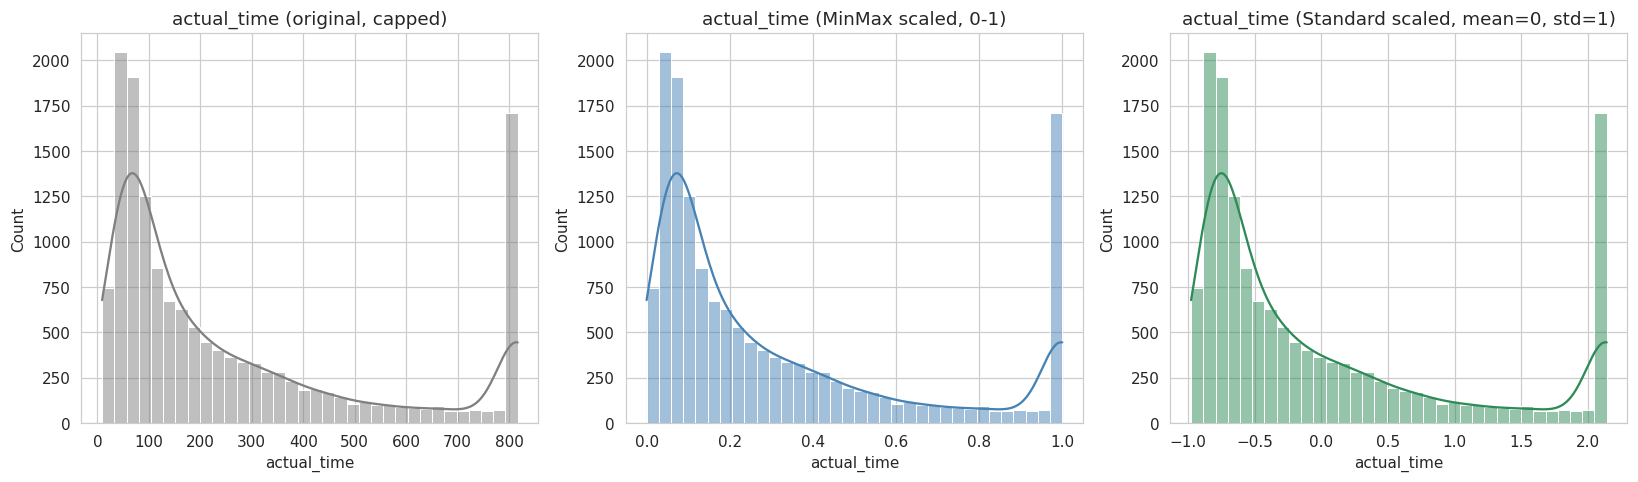

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.5))
sns.histplot(trip_encoded["actual_time"], ax=axes[0], kde=True, color="gray")
axes[0].set_title("actual_time (original, capped)")
sns.histplot(trip_minmax["actual_time"], ax=axes[1], kde=True, color="steelblue")
axes[1].set_title("actual_time (MinMax scaled, 0-1)")
sns.histplot(trip_standard["actual_time"], ax=axes[2], kde=True, color="seagreen")
axes[2].set_title("actual_time (Standard scaled, mean=0, std=1)")
plt.tight_layout()
plt.show()


**Observations:** Both scalers preserve the (capped) distribution's **shape** — only the scale changes. **MinMax scaling** squeezes every value into [0, 1], useful for algorithms sensitive to absolute feature ranges (e.g., neural networks, KNN). **Standard scaling** centers data at mean 0 with unit variance, generally preferred for linear/regularized models and PCA. For Delhivery's likely use case (forecasting delivery time/demand with tree-based or linear models), **StandardScaler** on the capped features is a solid default; **MinMaxScaler** is a reasonable alternative if a neural network is used downstream.

## 12. Business Insights

### 12.1 Where do most orders come from?

In [35]:
top_source_states = trip["source_state"].value_counts().head(10)
print("Top 10 source states by trip count:")
print(top_source_states)


Top 10 source states by trip count:
source_state
Maharashtra      2714
Karnataka        2143
Haryana          1823
Tamil Nadu       1039
Telangana         784
Uttar Pradesh     760
Gujarat           750
Delhi             725
West Bengal       665
Punjab            536
Name: count, dtype: int64


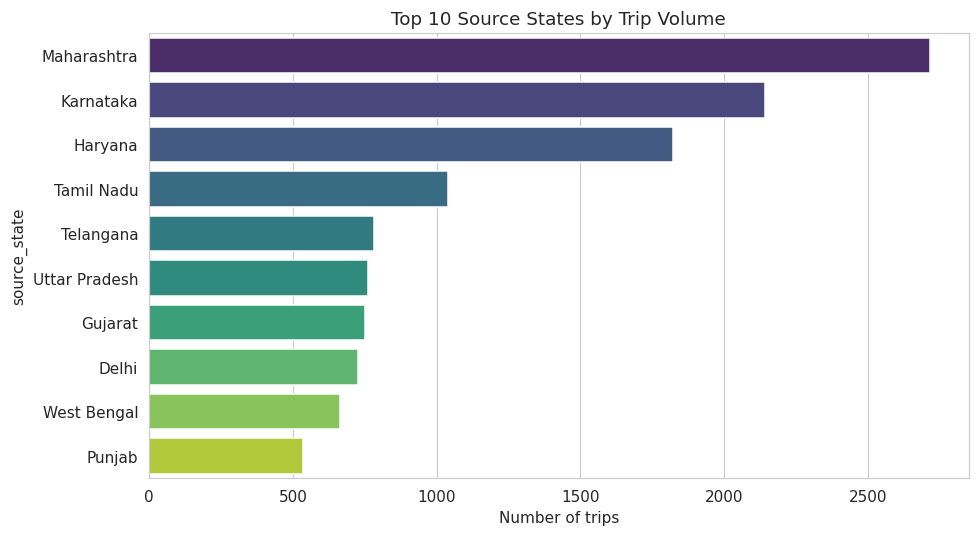

In [36]:
plt.figure(figsize=(9,5))
sns.barplot(x=top_source_states.values, y=top_source_states.index, hue=top_source_states.index, palette="viridis", legend=False)
plt.title("Top 10 Source States by Trip Volume")
plt.xlabel("Number of trips")
plt.tight_layout()
plt.show()


### 12.2 Busiest corridors

In [37]:
top_corridors = trip["corridor"].value_counts().head(10)
print("Top 10 busiest corridors:")
print(top_corridors)


Top 10 busiest corridors:
corridor
Bengaluru -> Bengaluru                581
Bangalore -> Bengaluru                455
Hyderabad -> Hyderabad                355
Mumbai -> Mumbai                      339
Bhiwandi -> Mumbai                    332
Bengaluru -> Bangalore                328
Gurgaon -> Delhi                      241
Mumbai Hub (Maharashtra) -> Mumbai    227
Chennai -> Chennai                    223
Mumbai -> Bhiwandi                    207
Name: count, dtype: int64


In [38]:
corridor_stats = trip.groupby("corridor").agg(
    n_trips=("trip_uuid","count"),
    avg_distance_km=("actual_distance_to_destination","mean"),
    avg_actual_time_min=("actual_time","mean")
).loc[top_corridors.index].round(1)
print(corridor_stats)


                                    n_trips  avg_distance_km  \
corridor                                                       
Bengaluru -> Bengaluru                  581             46.3   
Bangalore -> Bengaluru                  455             27.1   
Hyderabad -> Hyderabad                  355             56.1   
Mumbai -> Mumbai                        339             21.8   
Bhiwandi -> Mumbai                      332             23.0   
Bengaluru -> Bangalore                  328             29.8   
Gurgaon -> Delhi                        241             50.0   
Mumbai Hub (Maharashtra) -> Mumbai      227             16.3   
Chennai -> Chennai                      223             33.7   
Mumbai -> Bhiwandi                      207             21.6   

                                    avg_actual_time_min  
corridor                                                 
Bengaluru -> Bengaluru                            114.4  
Bangalore -> Bengaluru                             77.7  

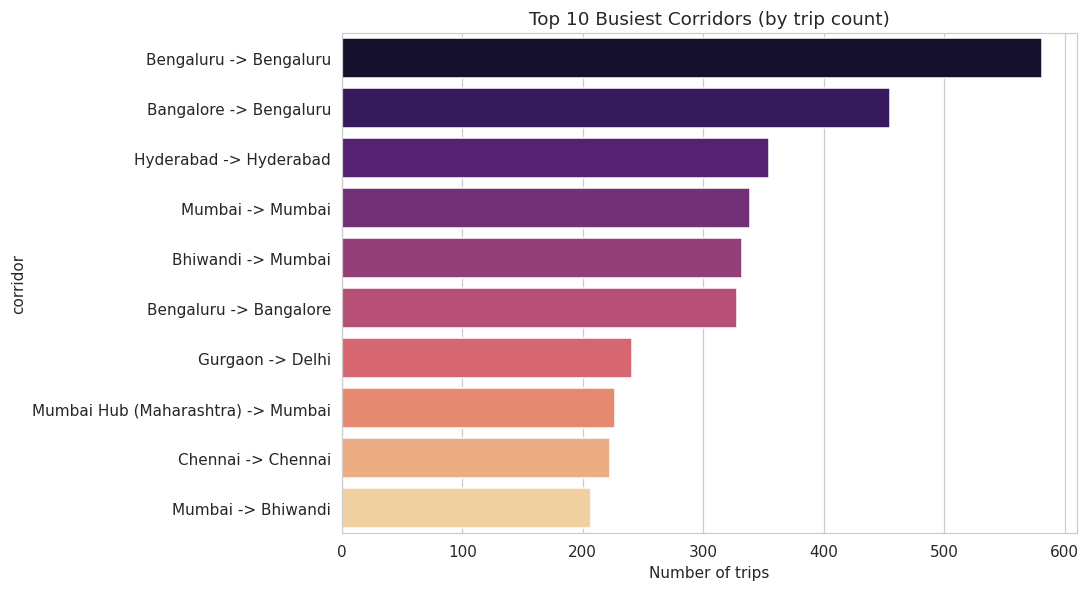

In [39]:
plt.figure(figsize=(10,5.5))
sns.barplot(x=corridor_stats["n_trips"], y=corridor_stats.index, hue=corridor_stats.index, palette="magma", legend=False)
plt.title("Top 10 Busiest Corridors (by trip count)")
plt.xlabel("Number of trips")
plt.tight_layout()
plt.show()


**Insights**
- **Maharashtra, Karnataka, and Haryana are the top three source states**, together accounting for a large share of all trips — these correspond to Delhivery's biggest hub cities (Mumbai, Bengaluru, Gurgaon/Delhi NCR).
- The single busiest corridor is **intra-city Bengaluru (Bengaluru -> Bengaluru)** with 581 trips, followed by Bangalore/Bengaluru naming variants (455) — together confirming **Bengaluru is Delhivery's single busiest hub** by a wide margin. Other high-traffic corridors include intra-Hyderabad, intra-Mumbai, Bhiwandi <-> Mumbai, Bengaluru <-> Bangalore, and Gurgaon -> Delhi.
- Many of the busiest "corridors" are actually **intra-city** (same city as both source and destination) — this reflects Delhivery's last-mile/local hub-and-spoke model as much as long-haul inter-city shipping.
- The busiest corridor (Bengaluru -> Bengaluru) has a relatively **short average distance (~46 km) and average actual time (~114 min)** — consistent with dense intra-city delivery rather than long-haul freight.

## 13. Recommendations for Delhivery

1. **Investigate the gap between scan-based duration and OD wall-clock duration** (Section 8.1: ~160 minutes on average). This likely represents hub waiting/handling time — auditing and reducing this at the busiest hubs (Bengaluru, Mumbai, Gurgaon) could meaningfully cut total delivery time without any change to the actual road travel.
2. **Stop using raw OSRM time as a customer-facing delivery estimate.** Actual delivery time is on average **more than 2x** the OSRM estimate (Section 8.2) — any ETA shown to customers or used for planning should apply a correction factor (or better, a model trained on the actual-vs-OSRM gap, segmented by route type and corridor) rather than the raw OSRM number.
3. **Standardize city naming** — we found the same city recorded under different names (e.g., "Bangalore" and "Bengaluru"), which fragments corridor-level reporting. Cleaning this up in the source system will make corridor/state analysis and dashboards more accurate immediately.
4. **Reconcile trip-level vs segment-level OSRM figures** (Sections 8.4-8.5) — the ~19 km / ~20 minute systematic gap between trip-level and summed-segment OSRM numbers suggests the routing engine isn't being called consistently (per-trip vs per-segment). Delhivery's engineering team should pick one as the "source of truth" for costing and pricing to avoid inconsistent numbers across reports.
5. **Prioritize operational excellence in the top 3-5 corridors** (led by intra-Bengaluru, intra-Hyderabad, intra-Mumbai, Bhiwandi-Mumbai, and Gurgaon-Delhi) — since a small number of corridors carry a disproportionate share of volume, small efficiency gains there (routing, staffing, vehicle allocation) will have an outsized impact on overall network performance.
6. **Treat FTL and Carting as operationally distinct products** in planning — FTL trips are far longer in distance and time (Section 6.3) and should be scheduled/resourced differently (dedicated trucks, fewer stops) than short-haul Carting trips.
7. **Use `actual_time`/`segment_actual_time_sum` interchangeably where convenient** (Section 8.3 showed they differ by <1% in practice) — this simplifies reporting without loss of accuracy, since chasing statistically-significant-but-practically-tiny differences wastes engineering effort.
8. **When building the forecasting model, drop redundant/highly-correlated features** (Section 7) — keep one clean representative of "trip size" (e.g., `osrm_distance` and `actual_time`) rather than feeding in 5+ near-duplicate time/distance columns, to avoid multicollinearity and improve model interpretability.

### Caveats
- This dataset spans **only about 3 weeks in September-October 2018** — seasonal patterns (festivals, monsoon, year-end peak) are not observable here; a longer time window is needed before drawing seasonal conclusions.
- All hypothesis tests used paired t-tests on the trip-level aggregated data; given the well-documented right-skew of these features, results should be read as **directionally reliable** (backed by very large sample sizes and consistent visual patterns) rather than as fully assumption-satisfying textbook tests.
